<a href="https://colab.research.google.com/github/GerardoMunoz/AlgLin_2025/blob/main/cuestionarios/SolTransfLin_2026_0202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nombre __________________________________ Código ___________________


> Para este cuestionario se da la matriz $A_1$ de mxn. Además, se dan las bases $B_1$, $B_2$ de $P_{m-1}$ y la base $B_3$ de $P_{n-1}$


1. Encuentre la transformación lineal $T:P_{n{-1}} \rightarrow P_{m{-1}}$, cuya matriz respecto a las bases estándar es la matriz $A_1$.

2. Para la transformación de la pregunta 1, encuentre una base para el núcleo $B_N$, una base para la imagen $B_I$, la nulidad, el rango y diga si es inyectiva, sobreyectiva o isomorfismo.

3.  Encuentre las matrices de cambio de base:
* $A_2$ para pasar de $B_2$ a $E_{Pm{-1}}$
* $A_3$ para pasar de $E_{Pm{-1}}$ a $B_2$
* $A_4$ para pasar de $B_1$ a $E_{Pm{-1}}$
* $A_5$ para pasar de $B_1$ a $B_2$

4. Encuentre la matriz $A_6$ de la transformación de la pregunta 1, usando la base $B_3$ para el dominio y la base $B_1$ para el codominio.

In [27]:
# Este código puede ser omitido
import matplotlib.pyplot as plt

def grafo(nodos,arcos,etiquetas=[]):
    fig, ax = plt.subplots()
    for nodo in nodos:
        nodo=nodos[nodo]
        ax.scatter(nodo[0],-nodo[1],s=20,color='k')
        ax.text(nodo[0],-nodo[1],'$'+nodo[2]+'$',fontsize=15)
    ax.axis('off')
    for nombre,nodo1,nodo2 in arcos:
        nodo1=nodos[nodo1]
        nodo2=nodos[nodo2]
        ax.arrow(float(nodo1[0]),-float(nodo1[1]),-float(nodo1[0])+float(nodo2[0]),float(nodo1[1])-float(nodo2[1]),head_width=0.07,head_length=0.2, length_includes_head=True)
        ax.text((nodo1[0]+nodo2[0])/2.0,-(nodo1[1]+nodo2[1])/2.0,'$'+nombre+'$',fontsize=18)
    for x,y,texto in etiquetas:
        ax.text(x,-y,'$'+texto+'$',fontsize=15)

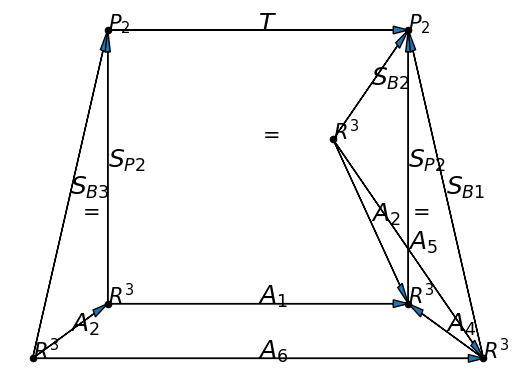

In [28]:
grafo({"P1":(1,1,"P_2"),"P3":(5,1,"P_2"),"B1":(0,4,"R^3"),"R2":(1,3.5,"R^3"),"R4":(5,3.5,"R^3"),"B3":(6,4,"R^3"),"B2":(4,2,"R^3")},
      [("T","P1","P3"),("S_{B3}","B1","P1"),("S_{P2}","R2","P1"),("S_{P2}","R4","P3"),("S_{B1}","B3","P3"),("S_{B2}","B2","P3"),
       ("A_2","B1","R2"), ("A_1","R2","R4"),("A_4","B3","R4"),("A_2","B2","R4"),("A_6","B1","B3"),("A_5","B2","B3")],
      [(0.6,2.7,"="),(3,2,"="),(5,2.7,"=")])

In [29]:
import sympy as sp
A1=sp.Matrix([[3, -2, 1],[6,-4,1],[-3,2,0]])
print(sp.latex(A1))

\left[\begin{matrix}3 & -2 & 1\\6 & -4 & 1\\-3 & 2 & 0\end{matrix}\right]


In [30]:
A1

Matrix([
[ 3, -2, 1],
[ 6, -4, 1],
[-3,  2, 0]])

$$B_1=[1, 1+x,1+x+x^2]$$
$$B_2=B3=[1,-1+x,-1-x+x^2]$$

1. Encuentre la transformación lineal $T:P_{n{-1}} \rightarrow P_{m{-1}}$, cuya matriz respecto a las bases estándar es la matriz $A_1$.

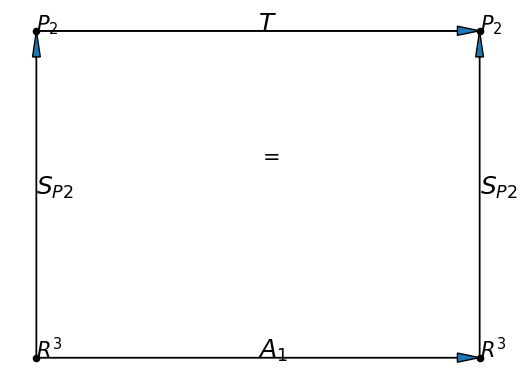

In [31]:
grafo({"P1":(1,1,"P_2"),"P3":(5,1,"P_2"),"R2":(1,3.5,"R^3"),"R4":(5,3.5,"R^3")},
      [("T","P1","P3"),("S_{P2}","R2","P1"),("S_{P2}","R4","P3"),
        ("A_1","R2","R4")],
      [(3,2,"=")])

$$T_{A}(a_0+a_1x+a_2x^2)=S_{P2}(A_1(S^{-1}_{P2}(a_0+a_1x+a_2x^2)))$$
$$T_{A}(a_0+a_1x+a_2x^2)=S_{P2}\left(A_1\begin{pmatrix}a_0\\a_1\\a_2\end{pmatrix}\right)$$
$$T_{A}(a_0+a_1x+a_2x^2)=S_{P2}\left(\left[\begin{matrix}3 & -2 & 1\\6 & -4 & 1\\-3 & 2 & 0\end{matrix}\right]\begin{pmatrix}a_0\\a_1\\a_2\end{pmatrix}\right)$$
$$T_{A}(a_0+a_1x+a_2x^2)=S_{P2}\left(\begin{matrix}3a_0   -2a_1 + a_2\\6a_0  -4a_1 + a_2\\-3a_0 + 2a_1 \end{matrix}\right)$$
$$T_{A}(a_0+a_1x+a_2x^2)=(3a_0   -2a_1 + a_2)+(6a_0  -4a_1 + a_2)x+(-3a_0 + 2a_1)x^2$$




2. Para la transformación de la pregunta 1, encuentre una base para el núcleo $B_N$, una base para la imagen $B_I$, la nulidad, el rango y diga si es inyectiva, sobreyectiva o isomorfismo.

El núcleo es el conjunto solución del sistema homegéneo

In [32]:
M=A1.row_join(sp.zeros(3,1))
M

Matrix([
[ 3, -2, 1, 0],
[ 6, -4, 1, 0],
[-3,  2, 0, 0]])

In [33]:
M[1,:]+=-2*M[0,:]
M[2,:]+=M[0,:]
M

Matrix([
[3, -2,  1, 0],
[0,  0, -1, 0],
[0,  0,  1, 0]])

In [34]:
M[2,:]+=M[1,:]
M

Matrix([
[3, -2,  1, 0],
[0,  0, -1, 0],
[0,  0,  0, 0]])

Los lugares de los pivotes son (0,0) y (1,2).

La variable libre es $$a_1=t_0$$

Despejamos las variables delanteras,desde la última
$$-a_2=0\rightarrow a_2=0$$
$$ 3a_0-2t_0+1(0)=0 \rightarrow a_0=\frac{2}{3}t_0$$
$$\begin{pmatrix}a_0\\a_1\\a_2\end{pmatrix}=t_0\begin{pmatrix}\frac{2}{3}\\1\\0\end{pmatrix}$$

Conclusiones sobre $A_1$
* La base del núcleo de $A_1$ es $\left\{\begin{pmatrix}\frac{2}{3}\\1\\0\end{pmatrix}\right\}$
* $\nu(A_1)=1$
* Geométricamente el núcleo es una recta  
* $T_{A1}$ no es inyectiva  
* La base de la imagen de $A_1$ es $\left[\begin{matrix}3 & 1\\6 & 1\\-3 & 0\end{matrix}\right]$
* $\rho(A_1)=2$
* Geométricamente la imagen es un plano  
* $T_{A1}$ no es sobreyectiva  

Conclusiones sobre $T$
* La base del núcleo de $T$ es $\{\frac{2}{3}+x+0x^2\}$
* $\nu(T)=1$
* $T$ no es inyectiva  
* La base de la imagen de $T$ es $[3+6x-3x^2, 1+x+0x^2]$
* $\rho(T)=2$
* $T$ no es sobreyectiva
* $T$ no es isomorfismo  

3.  Encuentre las matrices de cambio de base:
* $A_2$ para pasar de $B_2$ a $E_{Pm{-1}}$
* $A_3$ para pasar de $E_{Pm{-1}}$ a $B_2$
* $A_4$ para pasar de $B_1$ a $E_{Pm{-1}}$
* $A_5$ para pasar de $B_1$ a $B_2$

$$B_1=[1, 1+x,1+x+x^2]$$
$$B_2=[1,-1+x,-1-x+x^2]$$


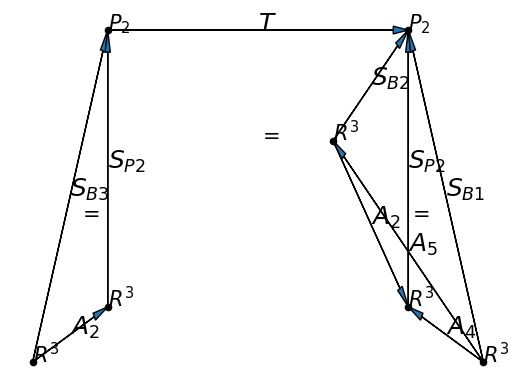

In [35]:
grafo({"P1":(1,1,"P_2"),"P3":(5,1,"P_2"),"B1":(0,4,"R^3"),"R2":(1,3.5,"R^3"),"R4":(5,3.5,"R^3"),"B3":(6,4,"R^3"),"B2":(4,2,"R^3")},
      [("T","P1","P3"),("S_{B3}","B1","P1"),("S_{P2}","R2","P1"),("S_{P2}","R4","P3"),("S_{B1}","B3","P3"),("S_{B2}","B2","P3"),
       ("A_2","B1","R2"),("A_4","B3","R4"),("A_2","B2","R4"),("A_5","B3","B2")],
      [(0.6,2.7,"="),(3,2,"="),(5,2.7,"=")])

$$A_2=S_{P2}^*(S^{*}_{B2}(I_2))$$

$$A_2=S_{P2}^*([1, -1+x,-1-x+x^2])$$

$$A_2=\begin{bmatrix}1 & -1 &-1\\0&1&-1\\0&0&1\end{bmatrix}$$

$$A3=A_2^{-1}$$

In [36]:
A2=sp.Matrix([[1,-1,-1],[0,1,-1],[0,0,1]])
A2

Matrix([
[1, -1, -1],
[0,  1, -1],
[0,  0,  1]])

In [37]:
M=A2.row_join(sp.eye(3))
M

Matrix([
[1, -1, -1, 1, 0, 0],
[0,  1, -1, 0, 1, 0],
[0,  0,  1, 0, 0, 1]])

In [38]:
M[1,:]+=M[2,:]
M[0,:]+=M[2,:]
M

Matrix([
[1, -1, 0, 1, 0, 1],
[0,  1, 0, 0, 1, 1],
[0,  0, 1, 0, 0, 1]])

In [39]:
M[0,:]+=M[1,:]
M

Matrix([
[1, 0, 0, 1, 1, 2],
[0, 1, 0, 0, 1, 1],
[0, 0, 1, 0, 0, 1]])

In [40]:
A3=M[:,3:]
A3

Matrix([
[1, 1, 2],
[0, 1, 1],
[0, 0, 1]])

Verificamos que $A3$ es la inversa de $A2$

In [41]:
A2@A3

Matrix([
[1, 0, 0],
[0, 1, 0],
[0, 0, 1]])

$$A_4=S_{P2}^*(S^{*}_{B1}(I_2))$$

$$A_4=S_{P2}^*([1, 1+x,1+x+x^2])$$

$$A_4=\begin{bmatrix}1 & 1 &1\\0&1&1\\0&0&1\end{bmatrix}$$

In [42]:
A4=sp.Matrix([[1,1,1],[0,1,1],[0,0,1]])

$$A_5=A_2^{-1}A_4$$
$$A_5=A_3A_4$$

In [43]:
A5=A3@A4
A5

Matrix([
[1, 2, 4],
[0, 1, 2],
[0, 0, 1]])

4. Encuentre la matriz $A_6$ de la transformación de la pregunta 1, usando la base $B_3$ para el dominio y la base $B_1$ para el codominio.

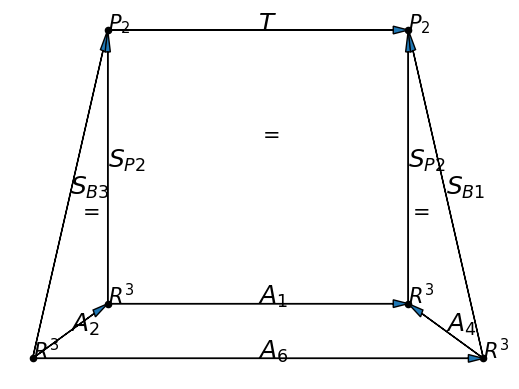

In [44]:
grafo({"P1":(1,1,"P_2"),"P3":(5,1,"P_2"),"B1":(0,4,"R^3"),"R2":(1,3.5,"R^3"),"R4":(5,3.5,"R^3"),"B3":(6,4,"R^3")},
      [("T","P1","P3"),("S_{B3}","B1","P1"),("S_{P2}","R2","P1"),("S_{P2}","R4","P3"),("S_{B1}","B3","P3"),
       ("A_2","B1","R2"), ("A_1","R2","R4"),("A_4","B3","R4"),("A_6","B1","B3")],
      [(0.6,2.7,"="),(3,2,"="),(5,2.7,"=")])

$$A_6=A_4^{-1}A_1A_2$$

Hallamos la inversa de A_4

In [45]:
M=A4.row_join(sp.eye(3))
M

Matrix([
[1, 1, 1, 1, 0, 0],
[0, 1, 1, 0, 1, 0],
[0, 0, 1, 0, 0, 1]])

In [46]:
M[1,:]-=M[2,:]
M[0,:]-=M[2,:]
M

Matrix([
[1, 1, 0, 1, 0, -1],
[0, 1, 0, 0, 1, -1],
[0, 0, 1, 0, 0,  1]])

In [47]:
M[0,:]-=M[1,:]
M

Matrix([
[1, 0, 0, 1, -1,  0],
[0, 1, 0, 0,  1, -1],
[0, 0, 1, 0,  0,  1]])

In [48]:
A4_inv=M[:,3:]
A4_inv

Matrix([
[1, -1,  0],
[0,  1, -1],
[0,  0,  1]])

In [49]:
A4@A4_inv

Matrix([
[1, 0, 0],
[0, 1, 0],
[0, 0, 1]])

In [50]:
A6=A4_inv@A1@A2
A6

Matrix([
[-3,   5,  1],
[ 9, -15, -2],
[-3,   5,  1]])

# Respuestas
1. $$T_{A}(a_0+a_1x+a_2x^2)=(3a_0   -2a_1 + a_2)+(6a_0  -4a_1 + a_2)x+(-3a_0 + 2a_1)x^2$$
2. Conclusiones sobre $T$
* La base del núcleo de $T$ es $\{\frac{2}{3}+x+0x^2\}$
* $\nu(T)=1$
* $T$ no es inyectiva  
* La base de la imagen de $T$ es $[3+6x-3x^2, 1+x+0x^2]$
* $\rho(T)=2$
* $T$ no es sobreyectiva
* $T$ no es isomorfismo  
3.


In [51]:
A2

Matrix([
[1, -1, -1],
[0,  1, -1],
[0,  0,  1]])

In [52]:
A3

Matrix([
[1, 1, 2],
[0, 1, 1],
[0, 0, 1]])

In [53]:
A4

Matrix([
[1, 1, 1],
[0, 1, 1],
[0, 0, 1]])

In [54]:
A5

Matrix([
[1, 2, 4],
[0, 1, 2],
[0, 0, 1]])

4.

In [55]:
A6

Matrix([
[-3,   5,  1],
[ 9, -15, -2],
[-3,   5,  1]])